In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import models, layers, optimizers
import scipy.io
import pandas as pd
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import gc
from PIL import Image
from pathlib import Path

gpus = tf.config.experimental.list_physical_devices('GPU')
print("GPU Available:", tf.config.list_physical_devices('GPU'))
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
def show_loss(hist):
    loss     = hist.history['loss']
    val_loss = hist.history['val_loss']
    epochs   = range(len(loss))
    plt.figure()
    plt.plot  ( epochs,loss )
    plt.plot  ( epochs,val_loss )
    plt.title ('Training and validation loss')

def show_accuracy(hist):
    acc = hist.history['accuracy']
    val_acc  = hist.history['val_accuracy']
    epochs   = range(len(acc))
    plt.figure()
    plt.plot  ( epochs,     acc )
    plt.plot  ( epochs, val_acc )
    plt.title ('Training and validation accuracy')

def export_crops(df, src_dir, dst_dir, margin=0.10):
    src_dir = Path(src_dir)
    dst_dir = Path(dst_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)

    for file, (x1, y1, x2, y2) in zip(df["file"], df["bbox"]):
        in_path  = src_dir / file
        out_path = dst_dir / file
        if out_path.exists():
            continue

        img = Image.open(in_path).convert("RGB")
        W, H = img.size

        pad_x = int((x2 - x1) * margin)
        pad_y = int((y2 - y1) * margin)

        x1p = max(0, x1 - pad_x)
        y1p = max(0, y1 - pad_y)
        x2p = min(W, x2 + pad_x)
        y2p = min(H, y2 + pad_y)

        if x2p <= x1p: x2p = min(W, x1p + 1)
        if y2p <= y1p: y2p = min(H, y1p + 1)

        crop = img.crop((x1p, y1p, x2p, y2p))
        out_path.parent.mkdir(parents=True, exist_ok=True)
        crop.save(out_path, quality=95)

In [3]:
train_annos = scipy.io.loadmat("data/cars_crops/cars_train_annos.mat")
test_annos  = scipy.io.loadmat("data/cars_crops/cars_test_annos.mat")

meta  = scipy.io.loadmat("data/cars_crops/cars_meta.mat")

train_annotations = train_annos['annotations'][0]
test_annotations = test_annos['annotations'][0]

classes = [c[0] for c in meta['class_names'][0]]

train_data = []
test_data = []

for a in train_annotations:
    train_data.append({
        "file": a[5][0],
        "class_id": int(a[4][0][0]),
        "bbox": (int(a[0][0][0]), int(a[1][0][0]), int(a[2][0][0]), int(a[3][0][0]))
    })

for a in test_annotations:
    test_data.append({
        "file": a[4][0],
        "class_id": None,
        "bbox": (int(a[0][0][0]), int(a[1][0][0]), int(a[2][0][0]), int(a[3][0][0]))
    })

train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

train_df, val_df = train_test_split(train_df, test_size=0.2,stratify=train_df["class_id"],random_state=42)

train_df["class_id"] = train_df["class_id"].astype(str)
val_df["class_id"] = val_df["class_id"].astype(str)

In [ ]:
# export_crops(train_df, "data/cars/cars_train/cars_train", "data/cars_crops/train")
# export_crops(val_df,   "data/cars/cars_train/cars_train", "data/cars_crops/val")
# export_crops(test_df,  "data/cars/cars_test/cars_test",   "data/cars_crops/test")

In [4]:
datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_dataframe(dataframe=train_df,directory="data/cars_crops/train", x_col="file", y_col="class_id",batch_size=32, class_mode='sparse', shuffle=True, seed=42, target_size=(224, 224))

val_gen = datagen.flow_from_dataframe(dataframe=val_df,directory="data/cars_crops/val", x_col="file", y_col="class_id",batch_size=32, class_mode='sparse', shuffle=False, seed=42, target_size=(224, 224))

test_gen = datagen.flow_from_dataframe(dataframe=test_df,directory="data/cars_crops/test", x_col="file", y_col=None,batch_size=32, class_mode=None, shuffle=False, seed=42, target_size=(224, 224))

Found 6515 validated image filenames belonging to 196 classes.
Found 1629 validated image filenames belonging to 196 classes.
Found 8041 validated image filenames.


Epoch 1/10
204/204 - 33s - loss: 5.2809 - accuracy: 0.0055 - val_loss: 5.2559 - val_accuracy: 0.0110 - 33s/epoch - 164ms/step
Epoch 2/10
204/204 - 23s - loss: 4.8850 - accuracy: 0.0559 - val_loss: 5.3849 - val_accuracy: 0.0153 - 23s/epoch - 112ms/step
Epoch 3/10
204/204 - 23s - loss: 2.8069 - accuracy: 0.3923 - val_loss: 7.7287 - val_accuracy: 0.0196 - 23s/epoch - 111ms/step
Epoch 4/10
204/204 - 23s - loss: 1.1705 - accuracy: 0.7317 - val_loss: 12.6819 - val_accuracy: 0.0153 - 23s/epoch - 112ms/step
Epoch 5/10
204/204 - 23s - loss: 0.4753 - accuracy: 0.8961 - val_loss: 18.6610 - val_accuracy: 0.0166 - 23s/epoch - 112ms/step
Epoch 6/10
204/204 - 22s - loss: 0.2085 - accuracy: 0.9601 - val_loss: 22.9817 - val_accuracy: 0.0172 - 22s/epoch - 109ms/step
Epoch 7/10
204/204 - 22s - loss: 0.1333 - accuracy: 0.9797 - val_loss: 25.9950 - val_accuracy: 0.0172 - 22s/epoch - 109ms/step
Epoch 8/10
204/204 - 22s - loss: 0.0842 - accuracy: 0.9880 - val_loss: 25.1936 - val_accuracy: 0.0196 - 22s/epoch 

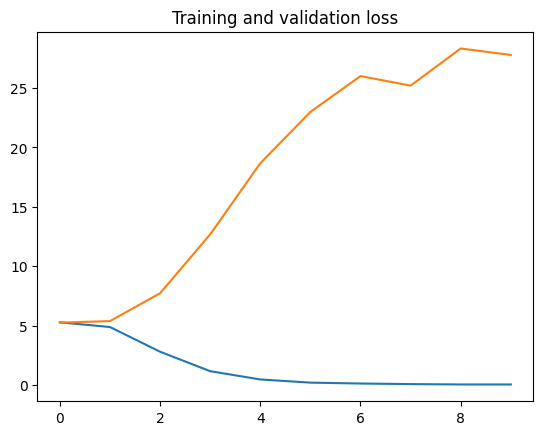

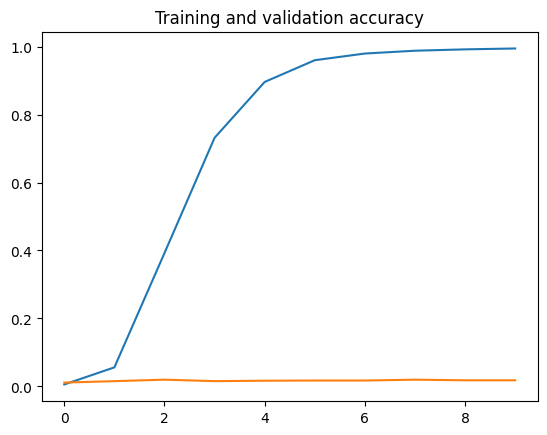

In [6]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(196, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_gen, epochs=10, validation_data=val_gen, verbose=2)
show_loss(history)
show_accuracy(history)

Epoch 1/10
204/204 [==============================] - 78s 306ms/step - loss: 5.2855 - accuracy: 0.0060 - val_loss: 5.2802 - val_accuracy: 0.0098
Epoch 2/10
204/204 [==============================] - 48s 236ms/step - loss: 5.1837 - accuracy: 0.0132 - val_loss: 5.1999 - val_accuracy: 0.0129
Epoch 3/10
204/204 [==============================] - 50s 243ms/step - loss: 5.1313 - accuracy: 0.0177 - val_loss: 5.1371 - val_accuracy: 0.0215
Epoch 4/10
204/204 [==============================] - 54s 266ms/step - loss: 5.0855 - accuracy: 0.0223 - val_loss: 5.0788 - val_accuracy: 0.0282
Epoch 5/10
204/204 [==============================] - 49s 240ms/step - loss: 5.0403 - accuracy: 0.0223 - val_loss: 5.0444 - val_accuracy: 0.0319
Epoch 6/10
204/204 [==============================] - 52s 256ms/step - loss: 4.9976 - accuracy: 0.0284 - val_loss: 5.0334 - val_accuracy: 0.0233
Epoch 7/10
204/204 [==============================] - 60s 293ms/step - loss: 4.9611 - accuracy: 0.0310 - val_loss: 4.9993 - val_ac

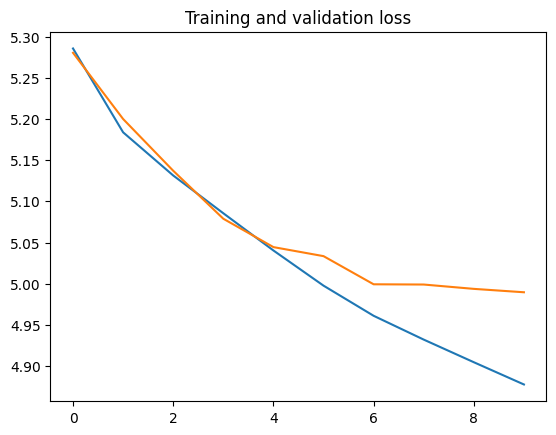

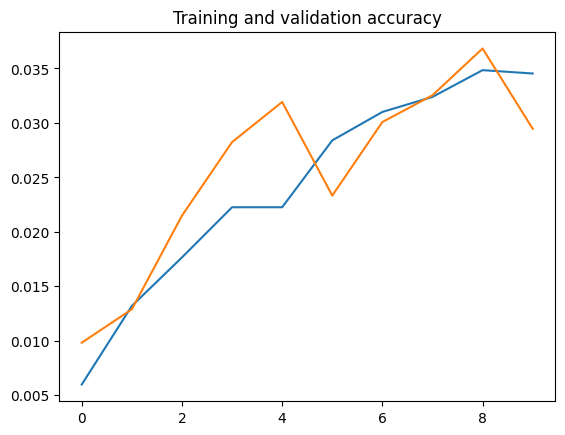

In [13]:
# Додав Dropout та регуляризацію
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3), kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(96, (3,3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(196, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

tf.keras.backend.clear_session()
gc.collect()

history = model.fit(train_gen, epochs=10, validation_data=val_gen, verbose=1)
show_loss(history)
show_accuracy(history)

In [6]:
# Змінив batch_size та додав аугментацію
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    #rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.05,
    zoom_range=0.15,
    brightness_range=[0.8,1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)

train_gen = datagen.flow_from_dataframe(dataframe=train_df,directory="data/cars_crops/train", x_col="file", y_col="class_id",batch_size=16, class_mode='sparse', shuffle=True, seed=42, target_size=(224, 224))

val_gen = datagen.flow_from_dataframe(dataframe=val_df,directory="data/cars_crops/val", x_col="file", y_col="class_id",batch_size=16, class_mode='sparse', shuffle=False, seed=42, target_size=(224, 224))

test_gen = datagen.flow_from_dataframe(dataframe=test_df,directory="data/cars_crops/test", x_col="file", y_col=None,batch_size=16, class_mode=None, shuffle=False, seed=42, target_size=(224, 224))

Found 6515 validated image filenames belonging to 196 classes.
Found 1629 validated image filenames belonging to 196 classes.
Found 8041 validated image filenames.


In [5]:
es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
rlr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

Epoch 1/10
408/408 [==============================] - 129s 296ms/step - loss: 5.2691 - accuracy: 0.0094 - val_loss: 5.2402 - val_accuracy: 0.0166 - lr: 0.0010
Epoch 2/10
408/408 [==============================] - 105s 257ms/step - loss: 5.1566 - accuracy: 0.0167 - val_loss: 5.1998 - val_accuracy: 0.0227 - lr: 0.0010
Epoch 3/10
408/408 [==============================] - 104s 253ms/step - loss: 5.1092 - accuracy: 0.0204 - val_loss: 5.1162 - val_accuracy: 0.0196 - lr: 0.0010
Epoch 4/10
408/408 [==============================] - 101s 246ms/step - loss: 5.0754 - accuracy: 0.0224 - val_loss: 5.0874 - val_accuracy: 0.0221 - lr: 0.0010
Epoch 5/10
408/408 [==============================] - 101s 247ms/step - loss: 5.0449 - accuracy: 0.0219 - val_loss: 5.1091 - val_accuracy: 0.0166 - lr: 0.0010
Epoch 6/10
408/408 [==============================] - 99s 242ms/step - loss: 5.0277 - accuracy: 0.0249 - val_loss: 5.2060 - val_accuracy: 0.0209 - lr: 0.0010
Epoch 7/10
408/408 [===========================

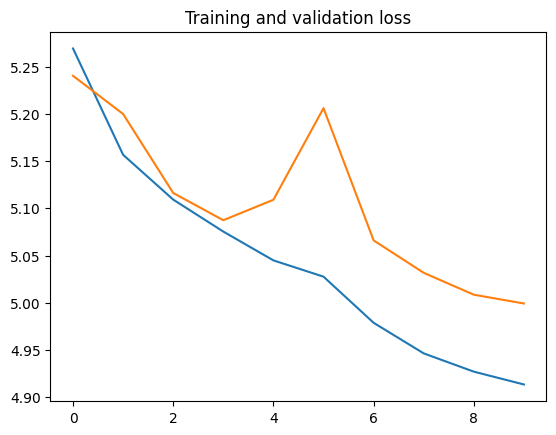

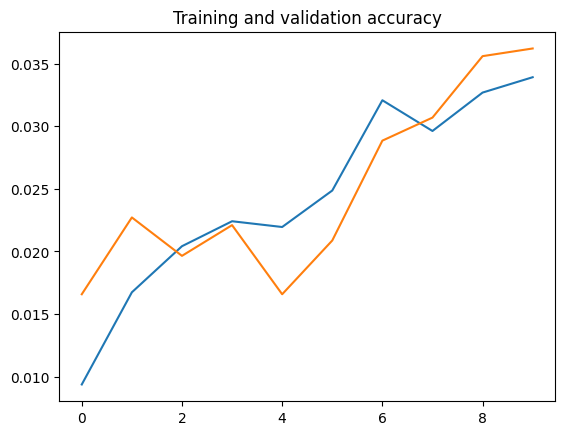

In [6]:
# Додав EarlyStopping та ReduceLROnPlateau
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3), kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(96, (3,3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(196, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

tf.keras.backend.clear_session()
gc.collect()

history = model.fit(train_gen, epochs=10, validation_data=val_gen, verbose=1, callbacks=[es, rlr])
show_loss(history)
show_accuracy(history)

Epoch 1/10
408/408 [==============================] - 98s 218ms/step - loss: 4.2533 - accuracy: 0.1355 - val_loss: 3.3722 - val_accuracy: 0.3076
Epoch 2/10
408/408 [==============================] - 91s 223ms/step - loss: 2.8418 - accuracy: 0.4064 - val_loss: 2.7514 - val_accuracy: 0.4082
Epoch 3/10
408/408 [==============================] - 82s 200ms/step - loss: 2.2114 - accuracy: 0.5414 - val_loss: 2.3705 - val_accuracy: 0.4929
Epoch 4/10
408/408 [==============================] - 92s 227ms/step - loss: 1.8336 - accuracy: 0.6183 - val_loss: 2.1737 - val_accuracy: 0.4936
Epoch 5/10
408/408 [==============================] - 101s 248ms/step - loss: 1.5519 - accuracy: 0.6772 - val_loss: 2.0090 - val_accuracy: 0.5378
Epoch 6/10
408/408 [==============================] - 83s 202ms/step - loss: 1.3679 - accuracy: 0.7147 - val_loss: 1.8877 - val_accuracy: 0.5421
Epoch 7/10
408/408 [==============================] - 99s 242ms/step - loss: 1.1890 - accuracy: 0.7578 - val_loss: 1.8095 - val_a

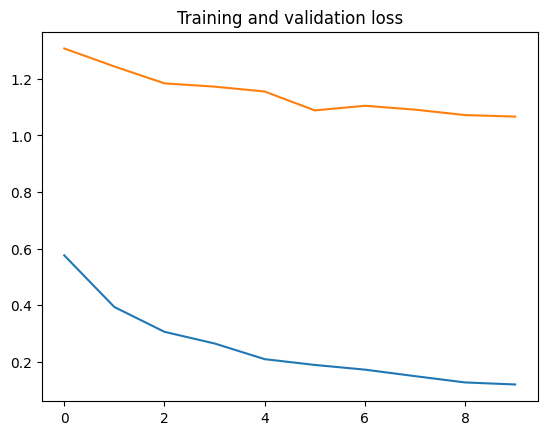

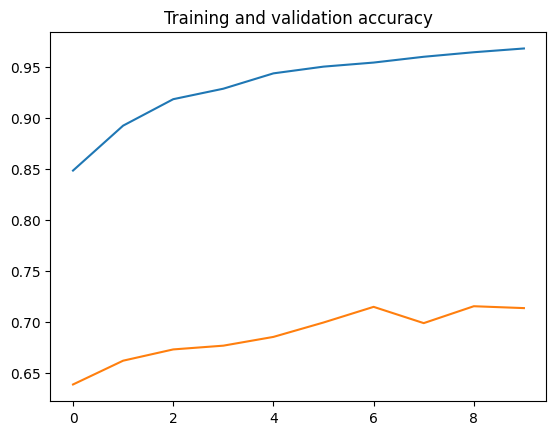

In [7]:
# Transfer learning
base = tf.keras.applications.EfficientNetB0(
    include_top=False, input_shape=(224,224,3), weights='imagenet')
base.trainable = False

inputs = tf.keras.Input((224,224,3))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(196, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_gen, epochs=10, validation_data=val_gen)

base.trainable = True
for layer in base.layers[:-20]:
    layer.trainable = False
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_gen, epochs=10, validation_data=val_gen)
show_loss(history)
show_accuracy(history)

In [112]:
model.save_weights('cars_model_weights.keras')

1/1 [==============================] - 0s 31ms/step


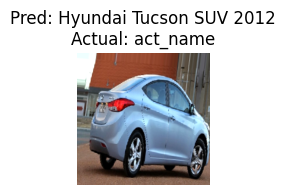

In [98]:
inv = {v: k for k, v in val_gen.class_indices.items()}

def idx_to_meta_name(idx: int) -> str:
    label_str = inv[idx]
    cid = int(label_str)
    return classes[cid - 1]

images = next(test_gen)
plt.figure(figsize=(5, 5))
for i in range(1):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].astype('uint8'))

    img = images[i][None, ...]
    prediction = model.predict(img)
    pred_idx = int(tf.argmax(prediction[0]).numpy())

    #act_idx = int(labels[i])

    pred_name = idx_to_meta_name(pred_idx)
    #act_name  = idx_to_meta_name(act_idx)

    plt.title(f"Pred: {pred_name}\nActual: {'act_name'}")
    plt.axis("off")

plt.tight_layout()
plt.show()